# Question 1 - Preprocessing

We start by defining some global variables to reference the columns of the table that we will be working with

In [1]:
unquote_col = ["race", "race_o", "field"]
encoding_cols = ["gender", "race", "race_o", "field"]
preferences = ["attractive_important", "sincere_important", "intelligence_important", 
            "funny_important", "ambition_important", "shared_interests_important"]

preferences_partner = ["pref_o_attractive", "pref_o_sincere", "pref_o_intelligence", "pref_o_funny", "pref_o_ambitious",
                    "pref_o_shared_interests"]

rating_of_partner = ["attractive_partner", "sincere_partner", "intelligence_partner", "funny_partner",
                    "ambition_partner", "shared_interests_partner"]

continuos_valued = ["age","age_o","importance_same_race","importance_same_religion","pref_o_attractive",
                    "pref_o_sincere","pref_o_intelligence","pref_o_funny","pref_o_ambitious","pref_o_shared_interests",
                    "attractive_important","sincere_important","intelligence_important","funny_important",
                    "ambition_important", "shared_interests_important","attractive","sincere","intelligence","funny",
                    "ambition","attractive_partner","sincere_partner","intelligence_partner","funny_partner",
                    "ambition_partner","shared_interests_partner","sports","tvsports","exercise","dining","museums",
                    "art","hiking","gaming","clubbing","reading","tv","theater","movies","concerts","music","shopping",
                    "yoga","interests_correlate","expected_happy_with_sd_people","like"]

maxval_ten = [ "importance_same_race","importance_same_religion", "attractive","sincere","intelligence","funny",
                    "ambition","attractive_partner","sincere_partner","intelligence_partner","funny_partner",
                    "ambition_partner","shared_interests_partner","sports","tvsports","exercise","dining","museums",
                    "art","hiking","gaming","clubbing","reading","tv","theater","movies","concerts","music","shopping",
                    "yoga", "like", "expected_happy_with_sd_people"]

        

Now we proceed by defining some auxiliary functions that will be used to preprocess

In [2]:
import csv
from globals import *
import databin as databin

from statistics import mean
import numpy as np
import matplotlib.pyplot as plt


# Performs label encoding in the database
# input:  the whole database already preprocessed
# output: a dictionary of encodings, indexed by each __encoding_cols__
# each index of the dictionary is lexicographically ordered, therefore the label the position of the value in this list
def label_encode(dic, enc_cols):
    # initialize the encoding dictionary
    enc = {}
    for enc_col in enc_cols:
        # we use sets for the label encoding, this way we always only add one element
        # each column in encoding_cols have a different set of label encodings
        enc[enc_col] = set()

    for row in dic:
        for enc_col in enc_cols:
            enc[enc_col].add(row[enc_col])
    
    for enc_col in enc_cols:
        enc[enc_col] = list(enc[enc_col])
        enc[enc_col].sort()

    return enc


def get_encoding(label, attr, encodings):
    for id, _label in enumerate(encodings[attr]):
        if label == _label:
            return id

    raise Exception

def encode_dic(dic, enc_cols, encodings):
    for row in dic:
        for attr in enc_cols:
            enc = get_encoding(row[attr], attr, encodings)
            row[attr] = enc
    
    return dic
            


def normalize(dic, prefs):
    total = 0

    # calculate total
    for row in dic:
        for preference in prefs:
            total += float(row[preference])

        # normalize
        for preference in prefs:
            row[preference] = float(row[preference]) / total
        total = 0
    

    return dic

# Unquotes the columns defined in __unquote_col__
# input: a row of dating-full in the form of dictionary
# output: (count, row)
#       count: number of unquoted cells
#       row: post processesd quote
def unquote(row):
    count = 0
    for col in unquote_col:
        cell = row[col]
        if cell.startswith("'") and cell.endswith("'") and len(cell) > 1:
            cell = cell.strip("'")
            count += 1
        if cell.startswith('"') and cell.endswith('"') and len(cell) > 1:
            cell = cell.strip('"')
            count += 1
        row[col] = cell
    return (count, row)

# Lowercases the __field__ column
# input: a row of dating-full in the form of a dictionary
# output: (count, row)
#       count: number of 
def tolower_field(row):
    count = 0
    if(not row["field"].islower()):
        count += 1
        row["field"] = row["field"].lower()
    return(count, row)

# Processes a dictionary by doing the following operations:
# 1 - unquote cells in unquote_col
# 2 - convert values in column field to lowercase
# input: csvDicReader
# output: (lower_count count, encodings, out_dic)
#       unq_count: number of unquoted cells
#       unq_count: number of lower cased field cells
#       label_encodings: encodings for the columns in encodings_val
#       outdic: preprocessed dictionary 
def preprocess(in_dic):
    unq_count = 0
    lower_count = 0
    out_dic = []
    for row in in_dic:
        c, row = unquote(row)
        c1, row = tolower_field(row)
        unq_count += c
        lower_count += c1
        out_dic.append(row)
    
    label_encodings = label_encode(out_dic, encoding_cols)
    out_dic = normalize(out_dic, preferences)
    out_dic = normalize(out_dic, preferences_partner)
    out_dic = encode_dic(out_dic, encoding_cols, label_encodings)
    return (unq_count, lower_count, label_encodings, out_dic)

def print_encodings(enc):
    for enc_col in encoding_cols:
        for id, val in enumerate(enc[enc_col]):
            if val == 'male' or (val == 'European/Caucasian-American' and enc_col == 'race') or (val == 'Latino/Hispanic American' and enc_col == 'race_o') or val == 'law':
                print("Value assigned for {} in column {}: {}".format(val, enc_col, id))
            

def print_means(dic):
    for pref in preferences + preferences_partner:
        col = [row[pref] for row in dic]
        print("Mean of {}: {}".format(pref, round(mean(col), 2)))



With all of this in place we are ready to output the desired outputs for the first question

## Question 1 - i)

By running the `preprocess` function we get al the output necessary and print them accordingly

In [3]:
with open('data/dating-full.csv', newline='') as csvfile:
    fulldata = csv.DictReader(csvfile, delimiter=',')
    unq_count, lower_count, label_encodings, dicdata = preprocess(fulldata)
    print("Quotes removed from", unq_count, "cells")
    

Quotes removed from 8316 cells


## Question 1 - ii) 

In [4]:
    print("Standardized", lower_count, "cells to lower case")

Standardized 5707 cells to lower case


## Question 1 - iii)

In [5]:

    print_encodings(label_encodings)


Value assigned for male in column gender: 1
Value assigned for European/Caucasian-American in column race: 2
Value assigned for Latino/Hispanic American in column race_o: 3
Value assigned for law in column field: 121


## Question 1 - iv)

In [6]:
    print_means(dicdata)

Mean of attractive_important: 0.22
Mean of sincere_important: 0.17
Mean of intelligence_important: 0.2
Mean of funny_important: 0.17
Mean of ambition_important: 0.11
Mean of shared_interests_important: 0.12
Mean of pref_o_attractive: 0.22
Mean of pref_o_sincere: 0.17
Mean of pref_o_intelligence: 0.2
Mean of pref_o_funny: 0.17
Mean of pref_o_ambitious: 0.11
Mean of pref_o_shared_interests: 0.12


Finally we the processed data in `data/dating.csv`

In [7]:
with open('data/dating.csv', 'w') as writefile:
        writer = csv.DictWriter(writefile, dicdata[0].keys())
        writer.writeheader()
        writer.writerows(dicdata)

# Question 2 - Visualizing interesting trends in data

## Question 2 i) barplot


Preference:  attractive_important
Male:  0.2611717324733246
Female:  0.17963070989377378

Preference:  sincere_important
Male:  0.1658662081727771
Female:  0.18339475722085816

Preference:  intelligence_important
Male:  0.1984411430404305
Female:  0.20913570422358307

Preference:  funny_important
Male:  0.17613518306570297
Female:  0.17278176768808653

Preference:  ambition_important
Male:  0.0872587409410902
Female:  0.13008502285557544

Preference:  shared_interests_important
Male:  0.11112699230667462
Female:  0.12497203811812302


<Figure size 640x480 with 0 Axes>

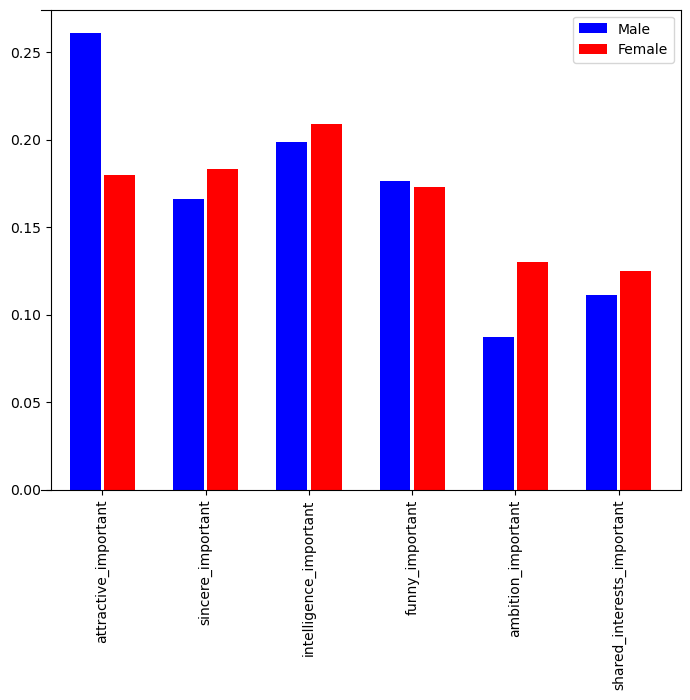

In [8]:
import csv

from statistics import mean
from globals import *

import numpy as np
import matplotlib.pyplot as plt


def plot_preferences_gender(dic):
    males = [row for row in dic if row['gender'] == '1']
    females = [row for row in dic if row['gender'] == '0']

    males_preferences = {}
    females_preferences = {}
    plt.tight_layout()
    # fig = plt.figure(figsize=(5,5))
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    X = np.arange(len(preferences))
    r = 0
    barwidth = .9
    barlocs = [
        [1, 2], 
        [4, 5], 
        [7, 8], 
        [10, 11], 
        [13, 14], 
        [16, 17]]
    for (pref, barloc) in zip(preferences, barlocs):
        male_pref = [float(row[pref]) for row in males]
        female_pref = [float(row[pref]) for row in females]

        males_preferences[pref] = mean(male_pref)
        females_preferences[pref] = mean(female_pref)
        print("\nPreference: ", pref)
        print("\rMale: ", males_preferences[pref])
        print("\rFemale: ", females_preferences[pref])

        ax.bar(barloc[0], males_preferences[pref], 
               width=barwidth, color='b', label=pref)

        ax.bar(barloc[1], females_preferences[pref], 
               width=barwidth, color='r', label=pref)


    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')

    plt.xticks([mean(barloc) for barloc in barlocs], preferences, rotation=90)

    plt.legend(["Male", "Female"])

    plt.savefig('graphs/importance.png', bbox_inches = 'tight')
    plt.show()

    return;


with open('data/dating.csv', 'r') as csvfile:
    dicdata = csv.DictReader(csvfile, delimiter=',')
    dicdata = list(dicdata)
    plot_preferences_gender(dicdata)
    

According to the data, males value attractiveness much more than woman. On the other hand, woman have a more balanced approach and values more equality the other qualities. In particular, woman seeks an ambition partner much more than men seeks an ambition partner.

<Figure size 640x480 with 0 Axes>

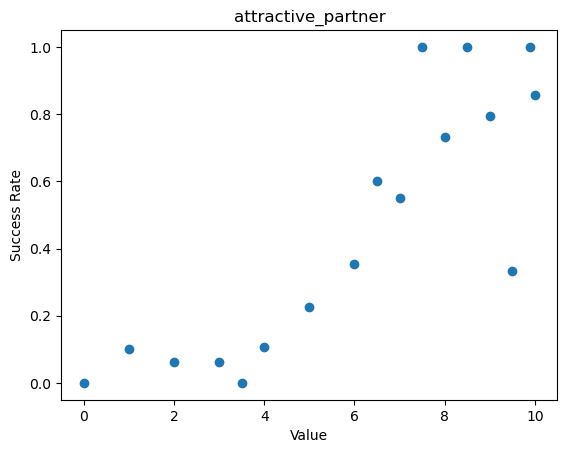

<Figure size 640x480 with 0 Axes>

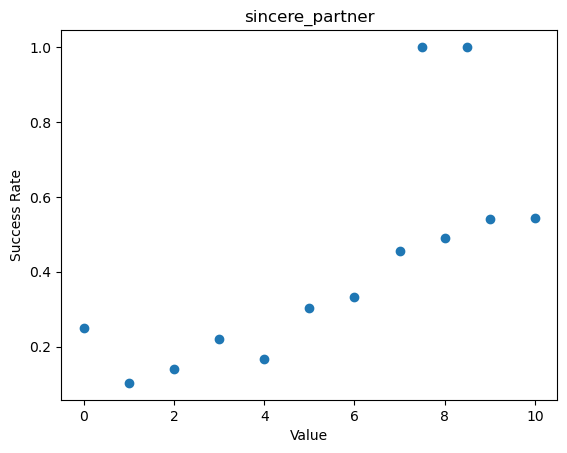

<Figure size 640x480 with 0 Axes>

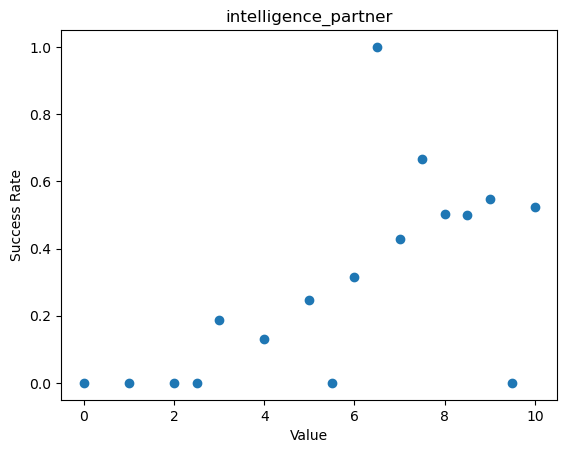

<Figure size 640x480 with 0 Axes>

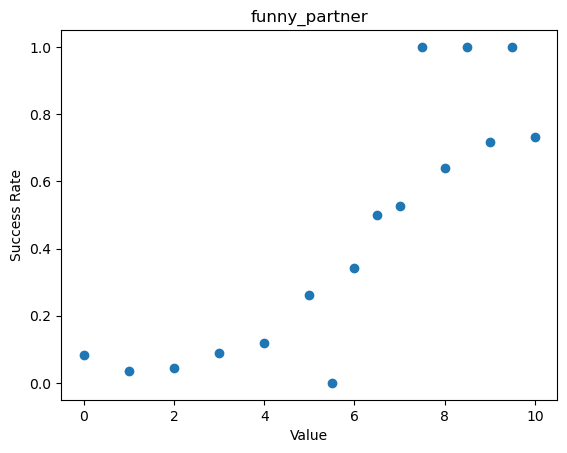

<Figure size 640x480 with 0 Axes>

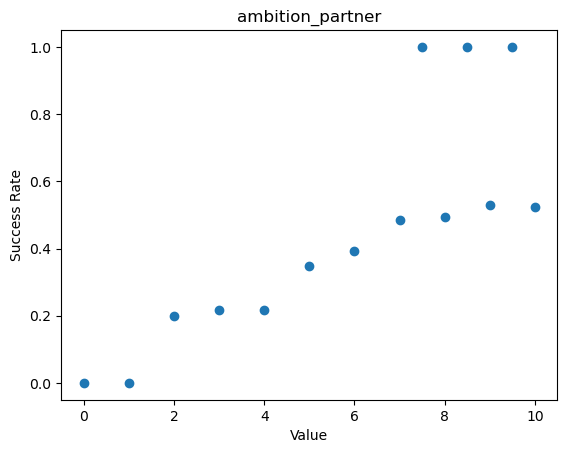

<Figure size 640x480 with 0 Axes>

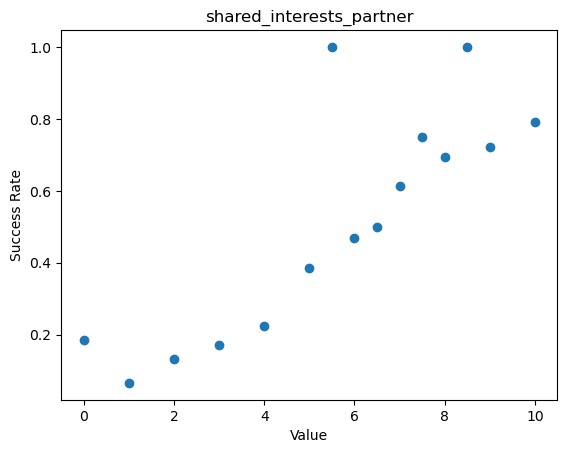

In [9]:

def second_date_by_rating(dic):
    # label_encodings = label_encode(dic, rating_of_partner)
    for rating in rating_of_partner:
        plt.tight_layout()
        fig = plt.figure()
        successes = []
        labels = list(set([float(x[rating]) for x in dic]))
        labels.sort()

        for label in labels:
            all_labels = [(float(x[rating]), x["decision"]) for x in dic if float(x[rating]) == label]
            positive_labels = [val for (val, dec) in all_labels if int(dec) == 1]
            success_rate = 0 if len(all_labels) == 0 else len(positive_labels) / len(all_labels)
            successes.append(success_rate)


        plt.scatter(labels, successes)
        plt.title(rating)
        plt.xlabel("Value")
        plt.ylabel("Success Rate")
        plt.savefig("graphs/"+rating+".png", bbox_inches = 'tight')
        plt.show()


    return;

second_date_by_rating(dicdata)

## Question 2 - ii)

From these scatter plots we can see that there is a linear relationship between the partner ratings and the success rate of a second date.

We provide comments for each attribute below:
* `attractive_partner`: The higher the attractiveness, the higher the chance of a second date. There are a few outliers in the data for points 7.5, 8.5 and 9.
* `sincere_partner`: We have a few outliers in the data, and it has a smaller factor as a decision a second date. This means that `sincere_partner` doesn't have a very high influence in the decision of a second date.
* `intelligence_partner`: There exists a threshod, meaning that if a partner scores below 2.5 then it has no chance of getting a date.
* `funny_partner`: This is also an attribute with a strong correlation of a chance of a second date, the higher the partner scores as funny, the higher the chance of a second date.
* `ambition_partner`: Not very higly correlated.
* `shared_interests_partner`: Highly correlated.

From these graphs we can infer that the most important attributes to decide for a second date are `attractive_partner`, `funny_partner` and `shared_interests_partner`.


# Question 3 - Convert continuous attributes to categorical attributes

In [10]:
def getminmax(dic):
    minmax_dic = {}

    for attr in continuos_valued:
        minval = 0
        if(attr == "age" or attr == "age_o"):
            minval = 18
            maxval = 58
        elif (attr in maxval_ten):
            maxval = 10
        elif (attr in preferences+preferences_partner):
            maxval = 1
        elif (attr == "interests_correlate"):
            minval = -1
            maxval = 1
        minmax_dic[attr] = (minval, maxval)
    
    return minmax_dic;

def binerize(dic, bin_num):
    binned_dic = []

    minmax_dic = getminmax(dic)
    not_continuous = [attr for attr in dic[0].keys() if not (attr in continuos_valued)]

    for row in dic:
        newrow = {}
        for col in continuos_valued:
            p = 0
            minval, maxval = minmax_dic[col]
            bin_size = float((maxval - minval) / bin_num)
            val = float(row[col])

            if val < minval + bin_size :
                newrow[col] = 0

            for i in range(1, bin_num):
                if minval + i*bin_size <= val < minval + (i+1)*bin_size:
                    newrow[col] = i

            if val >= minval + bin_num*bin_size:
                newrow[col] = bin_num-1

        for attr in not_continuous:
            newrow[attr] = row[attr]

        binned_dic.append(copy.deepcopy(newrow))
        
    return binned_dic;

def printbinsizes(binned_dic):
    for attr in continuos_valued:
        binsizes = [0, 0, 0, 0, 0]
        for row in binned_dic:
            for i in range(5):
                if row[attr] == i:
                    binsizes[i] += 1
                    
        print("{}: {}".format(attr, binsizes))
        

def bin(bin_num):
    with open('data/dating.csv', 'r') as csvfile:
        dicdata = csv.DictReader(csvfile, delimiter=',')
        binned = binerize(list(dicdata), bin_num)
        with open('data/dating-binned.csv', 'w') as writefile:
            writer = csv.DictWriter(writefile, binned[0].keys())
            writer.writeheader()
            writer.writerows(binned)
        return binned

import copy

binned = bin(5)
printbinsizes(binned)

age: [3032, 3491, 196, 20, 5]
age_o: [2990, 3495, 238, 16, 5]
importance_same_race: [2201, 1629, 897, 886, 1131]
importance_same_religion: [2507, 1475, 977, 848, 937]
pref_o_attractive: [3050, 2999, 615, 51, 29]
pref_o_sincere: [3699, 2960, 85, 0, 0]
pref_o_intelligence: [2515, 4091, 138, 0, 0]
pref_o_funny: [3924, 2760, 60, 0, 0]
pref_o_ambitious: [6258, 486, 0, 0, 0]
pref_o_shared_interests: [5671, 1073, 0, 0, 0]
attractive_important: [2990, 3103, 575, 57, 19]
sincere_important: [3775, 2884, 85, 0, 0]
intelligence_important: [2504, 4105, 135, 0, 0]
funny_important: [3934, 2750, 60, 0, 0]
ambition_important: [6246, 498, 0, 0, 0]
shared_interests_important: [5745, 999, 0, 0, 0]
attractive: [0, 131, 726, 3260, 2627]
sincere: [0, 57, 228, 1322, 5137]
intelligence: [0, 127, 409, 2157, 4051]
funny: [0, 9, 84, 1000, 5651]
ambition: [0, 225, 697, 1867, 3955]
attractive_partner: [87, 519, 1661, 2743, 1734]
sincere_partner: [37, 166, 818, 2646, 3077]
intelligence_partner: [14, 76, 657, 2696, 3

# Question 4 - Training-Test Split


In [11]:
import pandas as pd

""" inputs
        t_frac : percentage of data used for testing
        data   : data as pandas Dataframe
    output (test_sample, train_sample) pandas dataframes split into test and training data
        
"""
def sample(t_frac, data):
    sample = data.sample(random_state=47, frac=1, replace=False)

    test_frac = t_frac
    total_len = len(sample)
    test_len = int(test_frac*total_len)
    train_len = total_len - test_len

    train_sample = sample.head(train_len)
    test_sample = sample.tail(test_len-1)
    return (test_sample, train_sample)

def do_sample(t_frac=.2):
    data = pd.read_csv("data/dating-binned.csv")
    test_sample, train_sample = sample(t_frac, data)
    #print(f'test: {len(test_sample)} train: {len(train_sample)}')

    test_sample.to_csv("data/testSet.csv", index=False)
    train_sample.to_csv("data/trainingSet.csv", index=False)

do_sample()

# Question 5 - Implement a Naive Bayes Classifier

In [24]:
def nbc_helper(t_frac, bin_num):
    fulldata = pd.read_csv("data/dating.csv").to_dict('records')
    # print(fulldata)
    label_encodings = label_encode(fulldata, encoding_cols)
 
    
    train = pd.read_csv("data/trainingSet.csv")
    train = train.sample(random_state=47, frac=t_frac)
    print(len(train))

    dec_true = train[train['decision'] == 1]
    dec_false = train[train['decision'] == 0]
    dec_0 = len(dec_false)
    dec_1 = len(dec_true)

    total_size = dec_0 + dec_1


    probs = {}

    for attr in continuos_valued:
        probs[attr] = []
        for i in range(bin_num):
            deci_true = dec_true[dec_true[attr] == i]
            deci_false = dec_false[dec_false[attr] == i]
            
            # +bin_num is for laplacian smoothing
            # i.e. we are adding one extra element in each bin
            probs[attr].append(((len(deci_true)+1) / (dec_1+bin_num), (len(deci_false)+1) / (dec_0+bin_num)))
    
    c = continuos_valued + ["Unnamed: 0", "decision"]
    not_continuous = [attr for attr in train.columns if not (attr in c)]

    for attr in not_continuous: 
        if attr in label_encodings.keys():
            maxlabel = max(label_encodings[attr])+1
        else:
            l = [x[attr] for (i, x) in train.iterrows()]
            maxlabel = max(l+[0])+1
        probs[attr] = []
        for i in range(maxlabel):
            deci_true = dec_true[dec_true[attr] == i]
            deci_false = dec_false[dec_false[attr] == i]
            probs[attr].append(((len(deci_true)+1)/ (len(dec_true)+maxlabel), (len(deci_false)+1)/(len(dec_false)+maxlabel)))

    
    vals = []
    for attr in probs:
        s_1, s_0 = 0, 0
        for t,f in probs[attr]:
            s_1 += t
            s_0 += f
        vals.append((s_1, s_0))

    probs['decision'] = ((dec_1+1)/(total_size+2), (dec_0+1)/(total_size+2))

    
    return probs;

def nbc(t_frac):
    return nbc_helper(t_frac, 5)


def accuracy(probs, data):
    total_data = len(data)
    total_correct = 0

    for i, row in data.iterrows():
        dec_1, dec_0 = probs['decision']
        for attr in data:
            if attr == 'decision': continue
            bin = row[attr]
            try: 
                bin_1, bin_0 = probs[attr][bin]
            except IndexError as e:
                print(f"{e}")
                print("attr: {} bin: {}".format(attr, bin))
                print(len(probs[attr]))
                exit()
            dec_1 *= bin_1
            dec_0 *= bin_0
        classification = 1 if dec_1 > dec_0 else 0
        if classification == row['decision']:
            total_correct += 1
    acc = total_correct / total_data

    return acc;

probs = nbc(1)

train = pd.read_csv("data/trainingSet.csv")
test = pd.read_csv("data/testSet.csv")
train_acc = accuracy(probs, train)
test_acc = accuracy(probs, test)


5396


## Question 5 - 1)

In [19]:
print("Training accuracy: {:.2f}".format(train_acc))
print("Testing accuracy: {:.2f}".format(test_acc))

Training accuracy: 0.76
Testing accuracy: 0.74


## Question 5 - 2) 

In [20]:
bin_nums = [2, 5, 10, 50, 100, 200]

def many_bins():
    train_accs = []
    test_accs = []

    for i in bin_nums:
        bin(i)
        do_sample()

        probs = nbc_helper(1, i)
        train = pd.read_csv("data/trainingSet.csv")
        test = pd.read_csv("data/testSet.csv")
        # print(f'test: {len(test)} train: {len(train)}')

        train_acc = accuracy(probs, train)
        test_acc = accuracy(probs, test)

        print("Bin size: ", i)
        print("Training accuracy: {:.2f}".format(train_acc))
        print("Testing accuracy: {:.2f}".format(test_acc))
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    return (train_accs, test_accs)
    
train_accs, test_accs = many_bins()

Bin size:  2
Training accuracy: 0.71
Testing accuracy: 0.70
Bin size:  5
Training accuracy: 0.76
Testing accuracy: 0.74
Bin size:  10
Training accuracy: 0.78
Testing accuracy: 0.75
Bin size:  50
Training accuracy: 0.79
Testing accuracy: 0.76
Bin size:  100
Training accuracy: 0.79
Testing accuracy: 0.75
Bin size:  200
Training accuracy: 0.80
Testing accuracy: 0.76


<Figure size 640x480 with 0 Axes>

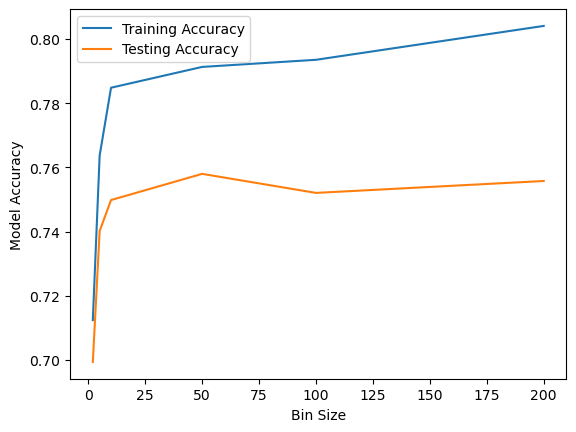

In [21]:
def plot_nbc_bins(train_accs, test_accs):
    plt.tight_layout()
    fig = plt.figure()

    plt.plot(bin_nums, train_accs)
    plt.plot(bin_nums, test_accs)

    plt.xlabel("Bin Size")
    plt.ylabel("Model Accuracy")
    plt.legend(["Training Accuracy", "Testing Accuracy"])

    plt.savefig('graphs/bin_accuracies.png')
    plt.show()


    return;


plot_nbc_bins(train_accs, test_accs)

We can see from the picture that the larger the amount of bins, the higher the accuracy of our results. Also, the accuracy is higher for the training dataset than for the testing dataset

## Question 5 - 3)


In [25]:
F = [0.01, 0.1, 0.2, 0.5, 0.6, 0.75, 0.9, 1]
def many_fracs():
    train_accs = []
    test_accs = []


    for i in F:
        bin(5)
        do_sample()

        probs = nbc(i)
        train = pd.read_csv("data/trainingSet.csv")
        test = pd.read_csv("data/testSet.csv")
        # print(f'test: {len(test)} train: {len(train)}')
        train_acc = accuracy(probs, train)
        test_acc = accuracy(probs, test)

        print("Sample Size: ", i)
        print("Training accuracy: {:.2f}".format(train_acc))
        print("Testing accuracy: {:.2f}".format(test_acc))
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    return(train_accs, test_accs)

train_accs, test_accs = many_fracs()

54
test: 1347 train: 5396
Sample Size:  0.01
Training accuracy: 0.70
Testing accuracy: 0.66
540
test: 1347 train: 5396
Sample Size:  0.1
Training accuracy: 0.74
Testing accuracy: 0.71
1079
test: 1347 train: 5396
Sample Size:  0.2
Training accuracy: 0.76
Testing accuracy: 0.73
2698
test: 1347 train: 5396
Sample Size:  0.5
Training accuracy: 0.76
Testing accuracy: 0.74
3238
test: 1347 train: 5396
Sample Size:  0.6
Training accuracy: 0.76
Testing accuracy: 0.74
4047
test: 1347 train: 5396
Sample Size:  0.75
Training accuracy: 0.76
Testing accuracy: 0.74
4856
test: 1347 train: 5396
Sample Size:  0.9
Training accuracy: 0.76
Testing accuracy: 0.74
5396
test: 1347 train: 5396
Sample Size:  1
Training accuracy: 0.76
Testing accuracy: 0.74


<Figure size 640x480 with 0 Axes>

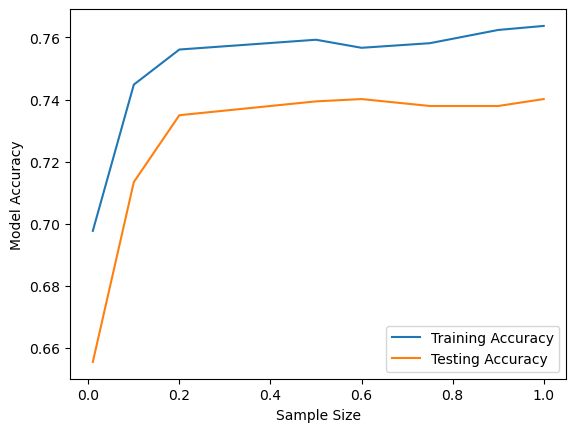

In [26]:
def plot_nbc_samples(bin_nums, train_accs, test_accs):
    plt.tight_layout()
    fig = plt.figure()

    plt.plot(bin_nums, train_accs)
    plt.plot(bin_nums, test_accs)
    plt.xlabel("Sample Size")
    plt.ylabel("Model Accuracy")
    plt.legend(["Training Accuracy", "Testing Accuracy"])
    plt.savefig('graphs/sample_accuracies.png')
    plt.show()


    return;

plot_nbc_samples(F, train_accs, test_accs)


From this plot we can see that the sample size doesn't have much effect on the accuracy of the Naive Bayes Classifier after a particular threshold, the threshold is 0.01. In any case, the accuracy is always higher in the training dataset than in the testing dataset, this is expected